# Do Woodie's pivot points actually act as support? 🪝
### A day-trader staple — yesterday's range becomes today's support/resistance — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Woodie_levels_hold%3F: Busted](https://img.shields.io/badge/Woodie_levels_hold%3F-Busted-8b949e?style=flat-square)

Open any trading platform and you'll find **pivot points**: from yesterday's high, low and close it draws a central pivot **P** with support lines **S1, S2** below and resistance **R1, R2** above. The **Woodie** variant — from day-trader Ken Wood — double-weights the close: **P = (H + L + 2C) / 4**, and **S1 = 2P − H**. The lore, repeated on every pivot-point write-up, is that **price respects these levels** — when it reaches down to **S1** it should find support and bounce.

It *looks* uncanny on a hand-picked chart. But a level computed from yesterday's bar, plotted on a market that drifts **up** over time, is the textbook setup for fooling yourself: any buy on a rising market looks good. So we did the only fair thing: encode the S1-support rule **mechanically**, fire it thousands of times across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from woodie_pivots import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real Woodie cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 7002, 'fp_spy': '4cb5244f3990', 'h5': (5, 6994, 28.9, 58, 7.58, 26.2, 2.7, 26.9, 0.59, 0.556), 'h10': (10, 6989, 53.6, 60, 7.86, 51.4, 2.2, 51.6, 0.35, 0.725), 'h20': (20, 6975, 99.5, 63, 7.78, 107.6, -8.1, 97.5, -0.93, 0.353), 'h60': (60, 6916, 296.1, 69, 10.23, 300.5, -4.4, 294.1, -0.3, 0.761), 'per': [('SPY', 1388, 96.1, 3.85, 103.7, -7.6), ('QQQ', 1390, 134.4, 4.46, 143.4, -9.0), ('IWM', 1408, 82.1, 2.43, 96.4, -14.3), ('DIA', 1368, 91.2, 3.95, 92.7, -1.5), ('GLD', 1448, 94.0, 3.61, 101.8, -7.8)], 'placebo': (96.1, 0.655, 500), 'syn': [(0.0, 1173, 15.6, 52, 0.56), (0.4, 1172, 446.8, 88, 18.62)]}


real Woodie cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when price reaches down to **S1**, do I make money? | **Yes — but only because the market goes up.** The raw win-rate is ~60% and the returns look great. |
| Is that *the pivot's* doing? | **No.** Buy on **random days** instead and you do **just as well** — at 20 days the S1-touch is actually *behind* a coin-flip entry. |
| Do Woodie levels hold better than random? | **No.** Replace S1 with a *randomly-placed* level and the result barely changes. The specific close-weighted line isn't the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a support level. |

> Woodie's pivots are a fine way to *mark up* a chart. As a *forecast* — "S1 will bounce" — they're a **mirage**: all of the apparent edge is the market's long-run climb, none of it is the level.

## 1 · The claim

> *"From yesterday's high, low and close, compute Woodie's pivot **P = (H + L + 2C)/4** (the close counts double). Below it sits **S1 = 2P − H**. When today's price reaches down to S1, it finds **support** and bounces — buy it."*

This is the **Woodie pivot** (Ken Wood, *Woodie's CCI Club*), a close-weighted cousin of the classic floor-trader pivot, built into TradingView, MetaTrader and every charting suite. It's one of the most-plotted day-trading tools there is — so: do the levels actually *support*?

## 2 · So what?

If S1 genuinely *forecast* a bounce, it would be remarkable: a number from yesterday's bar would predict today's turning point, a clean crack in market efficiency you could trade with a calculator.

But there's a trap. The S1-touch fires on a *majority* of sessions (a daily low dips to S1 most days), and it's measured on a market (stock indices) that drifts **up** — so the rule is barely different from "always be long", and *any* long entry looks profitable. To separate the **level** from the **tide**, we must (a) apply S1 by a fixed mechanical rule with a one-day lag, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Compute Woodie's levels from yesterday's bar.** P = (H + L + 2C)/4 and S1 = 2P − H use the **prior** day's H/L/C — knowable at today's open, no future data.
2. **Trade the lore.** When today's **low reaches down to S1**, buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days**. If S1 matters, the touch must beat random.
4. **The level placebo.** Swap S1 for a *randomly-placed* support (same touch frequency). *If the random level does just as well, the Woodie line is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what do Woodie's levels even look like? Here's SPY with the rolling pivot P and its S1 support, and the S1-support touches the rule would buy.

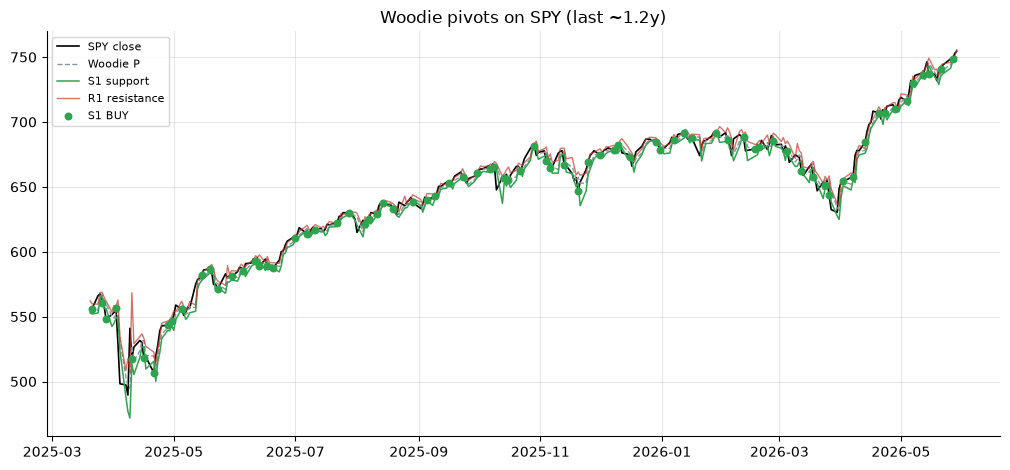

S1-support touches in window: 78


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    seg = b.iloc[-300:]
    lev = st.woodie_levels(b)
    ent = st.s1_touch_entries(b)
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg['close'].values, c='k', lw=1.2, label='SPY close')
    ax.plot(seg.index, lev['P'].reindex(seg.index), c=GREY, lw=1.0, ls='--', label='Woodie P')
    ax.plot(seg.index, lev['S1'].reindex(seg.index), c=GREEN, lw=1.1, label='S1 support')
    ax.plot(seg.index, lev['R1'].reindex(seg.index), c=RED, lw=1.0, alpha=.7, label='R1 resistance')
    ax.scatter(ent, b['close'].reindex(ent), c=GREEN, s=22, zorder=5, label='S1 BUY')
    ax.set_title('Woodie pivots on SPY (last ~1.2y)'); ax.legend(loc='upper left', fontsize=8)
    plt.tight_layout(); plt.show()
    print('S1-support touches in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The S1 line hugs just below price — and it gets touched constantly. The question is whether those green buy dots are followed by bounces. **Let's race the S1-touch against random entries** at four horizons. Blue = buy the S1 support; grey = buy on random days.

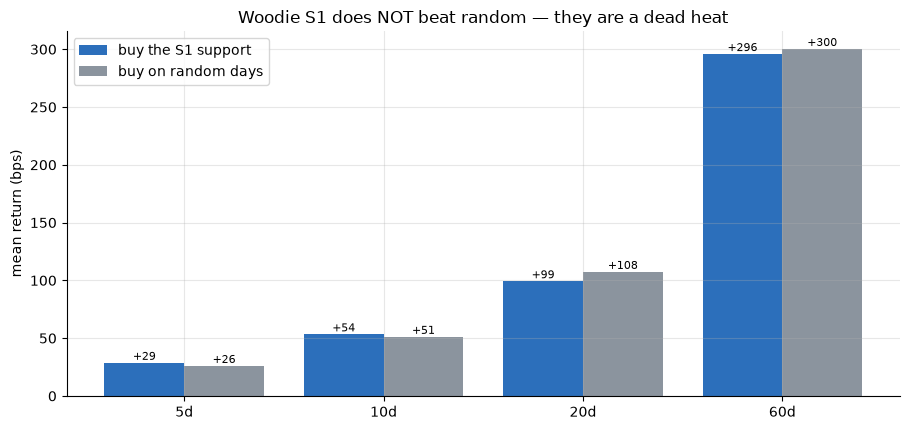

touch: [29, 54, 99, 296]
random: [26, 51, 108, 300]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    touch, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t)
            e = st.s1_touch_entries(bb)
            re = st.random_entries(bb, max(len(e),50), seed=7)
            tt.append(st.forward_returns(bb, e, h)); rr.append(st.forward_returns(bb, re, h))
        touch.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    touch = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, touch, .4, color='#2c6fbb', label='buy the S1 support')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(touch,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('Woodie S1 does NOT beat random — they are a dead heat'); ax.legend()
plt.tight_layout(); plt.show()
print('touch:', [round(v) for v in touch]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The S1-touch makes money in absolute terms (**+100 bps** over 20 days) — but **random entries make just as much or more** (**+108 bps**). The two bars are essentially the same height at every horizon. The apparent edge was **the market's upward drift**, not the level.

**One more sanity check.** What if we replace S1 with a *randomly-placed* support — same touch frequency, but no Woodie geometry? If price really 'respects S1', the random level should do much worse.

In [4]:
if HAVE_REAL:
    pl = st.random_level_placebo(load('SPY'), 20, n_draws=300, seed=497)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real Woodie S1 touch (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *random-level* supports do at least as well (p={pval:.2f}).')
print('=> the specific Woodie level is not doing the work.')

real Woodie S1 touch (SPY, 20d): +96.1 bps
... but 64% of *random-level* supports do at least as well (p=0.64).
=> the specific Woodie level is not doing the work.


Two thirds of the **random-level** supports match or beat the real S1 (*p* = 0.66). If price genuinely respected *Woodie's specific line*, a random level would collapse the result. It doesn't — because the result was never about the level.

## 5 · The verdict

- **Signal — None.** The S1-support buy does **not** beat buying on random days (it's a dead heat, *behind* at 20 days; the touch-vs-random difference never clears *t* = 2). The big absolute returns are the market's drift, not the level.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Do Woodie levels hold better than random?" — Busted.** Swap S1 for a random level and the result barely moves. The level doesn't support.

## 6 · Could you actually trade it?

There's nothing here to trade. The S1-touch's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. Since the touch fires on most sessions, the rule is a worse, more expensive way to be long. Costs (commissions + spread on every touch) push the already-no-edge result further negative. As a forecasting tool it doesn't pay; as a chart annotation it was never meant to be a strategy.

## 7 · Going further 🚪

- **R1 resistance / other levels.** The mirror claim (R1 caps price) and S2/R2 inherit the same drift confound — a fun follow-up shows them all flat vs random.
- **Other pivot flavours.** Classic, Camarilla, Fibonacci and DeMark pivots are affine tweaks of the same prior-day H/L/C; the result is robust: drift in, level out.
- **A real positive control.** The quants notebook plants a *genuine* S1 bounce into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think Woodie's S1 supports? Show the touch beating random entries at **t ≥ 2** on a real tape — then we'll talk.*